In [1]:
# 필요한 라이브러리를 임포트합니다
import platform
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

# ========================================
# 운영체제별 한글 폰트 설정
# ========================================
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

print("라이브러리 로드 완료")

/Users/jin/Develop/codingclub/game-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


라이브러리 로드 완료


In [2]:
df_reviews = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')
print(f'전체 리뷰: {len(df_reviews):,}건 로드 완료')

전체 리뷰: 166,875건 로드 완료


In [3]:
# 분석 대상 게임 설정
TARGET_APPID = 1214470
# 리뷰 최소 텍스트 수
min_length = 10

df_game = (
    df_reviews[
        (df_reviews['appid'] == TARGET_APPID) &
        (df_reviews['language'] == 'english')
    ]
    .dropna(subset=['review'])
    .pipe(lambda d: d[d['review'].str.strip() != ''])
    .pipe(lambda d: d[d['review'].str.len() >= min_length])
    .reset_index(drop=True)
)

In [4]:
# df_game 기반으로 분석용 변수를 추출합니다
filtered_docs = df_game['review'].tolist()
filtered_labels = df_game['voted_up'].astype(int).values  # True/False → 1/0
label_names = {1: '긍정', 0: '부정'}

# 긍정/부정 분리
df_neg = df_game[~df_game['voted_up']].reset_index(drop=True)
df_pos = df_game[df_game['voted_up']].reset_index(drop=True)
neg_docs = df_neg['review'].tolist()
pos_docs = df_pos['review'].tolist()

print(f"분석 대상: {len(filtered_docs):,}건 (최소 {min_length}자 이상, 영어)")
print(f"  긍정: {len(pos_docs):,}건 / 부정: {len(neg_docs):,}건")

분석 대상: 969건 (최소 10자 이상, 영어)
  긍정: 732건 / 부정: 237건


In [5]:
# 필터링 결과를 확인합니다
print("필터링된 데이터 미리보기 (5건):")
display(df_game[['voted_up', 'review']].head())

print()
print("텍스트 길이 통계:")
display(df_game['review'].str.len().describe().to_frame("review_length").T)

필터링된 데이터 미리보기 (5건):


,voted_up,review
0,True,This is a really great game. Also i encountere...
1,True,"Very surprised by this. The graphics are good,..."
2,True,One of best game ever I played! Thats similar ...
3,True,Best renovator game out there. If you liked Ho...
4,True,LOVE this game!!! I am a huge fan of House Fli...



텍스트 길이 통계:


,count,mean,std,min,25%,50%,75%,max
review_length,969.0,467.068111,782.46782,10.0,73.0,191.0,526.0,7857.0


In [6]:
# 임베딩 모델을 로드합니다
embedding_model = SentenceTransformer("avsolatorio/GIST-small-Embedding-v0") #허깅페이스 라이브러리

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4975.78it/s]


In [7]:
import os

def load_or_encode(docs: list[str], path: str) -> np.ndarray:
    if os.path.exists(path):
        embeddings = np.load(path)
        print(f"로드 완료: {path} {embeddings.shape}")
    else:
        print(f"{len(docs):,}건 임베딩 생성 중...")
        embeddings = embedding_model.encode(docs, show_progress_bar=True)
        np.save(path, embeddings)
        print(f"저장 완료: {path} {embeddings.shape}")
    return embeddings

neg_embeddings = load_or_encode(neg_docs, f'../../../../data/processed/embeddings_neg_{TARGET_APPID}.npy')
pos_embeddings = load_or_encode(pos_docs, f'../../../../data/processed/embeddings_pos_{TARGET_APPID}.npy')

로드 완료: ../../../../data/processed/embeddings_neg_1214470.npy (237, 384)
로드 완료: ../../../../data/processed/embeddings_pos_1214470.npy (732, 384)


In [8]:
def build_topic_model(min_cluster_size: int) -> BERTopic:
    umap_model = UMAP(
        n_components=5,
        n_neighbors=15,
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=3,
        metric="euclidean"
    )
    vectorizer_model = CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )
    return BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        verbose=False,
    )

print("부정 리뷰 BERTopic 학습 중...")
topic_model_neg = build_topic_model(min_cluster_size=20)  # 237건의 약 8%
neg_topics, neg_probs = topic_model_neg.fit_transform(neg_docs, embeddings=neg_embeddings)
df_neg['topic'] = neg_topics
n_noise_neg = neg_topics.count(-1)
print(f"  토픽 수: {len(set(neg_topics)) - 1}개 / 노이즈: {n_noise_neg}건 ({n_noise_neg/len(neg_topics)*100:.1f}%)")

print("\n긍정 리뷰 BERTopic 학습 중...")
topic_model_pos = build_topic_model(min_cluster_size=40)  # 732건의 약 5%
pos_topics, pos_probs = topic_model_pos.fit_transform(pos_docs, embeddings=pos_embeddings)
df_pos['topic'] = pos_topics
n_noise_pos = pos_topics.count(-1)
print(f"  토픽 수: {len(set(pos_topics)) - 1}개 / 노이즈: {n_noise_pos}건 ({n_noise_pos/len(pos_topics)*100:.1f}%)")

부정 리뷰 BERTopic 학습 중...
  토픽 수: 2개 / 노이즈: 12건 (5.1%)

긍정 리뷰 BERTopic 학습 중...
  토픽 수: 6개 / 노이즈: 71건 (9.7%)


In [9]:
# 토픽 요약 확인
neg_topic_info = topic_model_neg.get_topic_info()
pos_topic_info = topic_model_pos.get_topic_info()

print("=== 부정 리뷰 토픽 요약 ===")
display(neg_topic_info)

print("\n=== 긍정 리뷰 토픽 요약 ===")
display(pos_topic_info)

=== 부정 리뷰 토픽 요약 ===


,Topic,Count,Name,Representation,Representative_Docs
0,-1,12,-1_broken furniture_paid dlc_bugs_paid,"[broken furniture, paid dlc, bugs, paid, quali...",[Really wanted to love this game. I wouldn't h...
1,0,204,0_bugs_room_floor_don,"[bugs, room, floor, don, furniture, hotel, dev...",[It's such a waste and a shame that no one too...
2,1,21,1_screen_loading_came_crashed,"[screen, loading, came, crashed, error, loadin...",[Can't play it. It just keeps crashing on the ...



=== 긍정 리뷰 토픽 요약 ===


,Topic,Count,Name,Representation,Representative_Docs
0,-1,71,-1_chicken_hours_10_time,"[chicken, hours, 10, time, games, hotel, graph...",[~ DIFFICULTY ~\n\n🔲 My 90 year old grandma co...
1,0,308,0_room_bugs_hotel_furniture,"[room, bugs, hotel, furniture, rooms, floor, t...",[A true hidden gem that just stealth dropped o...
2,1,146,1_great game_love game_good game_game love,"[great game, love game, good game, game love, ...","[great game 10/10, Awesome game, usually I don..."
3,2,84,2_house_flipper_house flipper_like house,"[house, flipper, house flipper, like house, si...","[Its house flipper but for hotels, It's like H..."
4,3,43,3_fun fun_super_great fun_fun really,"[fun fun, super, great fun, fun really, good f...","[Good fun, worth the money for sure., This is ..."
5,4,40,4_relaxing_relaxing game_chill_game relaxing,"[relaxing, relaxing game, chill, game relaxing...","[This game is relaxing., Very nice relaxing ga..."
6,5,40,5_hotel_renovation_hotel renovator_renovator,"[hotel, renovation, hotel renovator, renovator...","[""I recently played the Hotel Renovator game, ..."


**해석:** 각 토픽의 `Count`는 해당 토픽에 배정된 리뷰 수이며, `-1`은 어떤 토픽에도 속하지 않은 노이즈 리뷰입니다.
노이즈 비율이 높을수록 리뷰 간 주제가 분산되어 있음을 의미합니다.
토픽 수와 노이즈 비율을 함께 확인하여 `min_cluster_size` 파라미터 적절성을 판단하세요.

In [10]:
# 토픽별 상위 키워드 인터랙티브 차트
neg_topic_ids = [t for t in neg_topic_info["Topic"] if t != -1]
pos_topic_ids = [t for t in pos_topic_info["Topic"] if t != -1]

print("=== 부정 리뷰 토픽별 키워드 ===")
topic_model_neg.visualize_barchart(
    top_n_topics=len(neg_topic_ids),
    n_words=8,
    title=f'부정 리뷰 토픽별 키워드 (appid={TARGET_APPID})',
    width=300,
)

=== 부정 리뷰 토픽별 키워드 ===


In [11]:
print("=== 긍정 리뷰 토픽별 키워드 ===")
topic_model_pos.visualize_barchart(
    top_n_topics=len(pos_topic_ids),
    n_words=8,
    title=f'긍정 리뷰 토픽별 키워드 (appid={TARGET_APPID})',
    width=300,
)

=== 긍정 리뷰 토픽별 키워드 ===


In [12]:
def print_representative_reviews(topic_model: BERTopic, df: pd.DataFrame, topic_info: pd.DataFrame, top_n_topics: int = 5, top_n_words: int = 3) -> None:
    """각 토픽에서 c-TF-IDF 점수가 높은 상위 키워드를 가진 대표 리뷰를 출력합니다."""
    info = topic_info[topic_info['Topic'] != -1].head(top_n_topics)

    for _, row in info.iterrows():
        topic_id = row['Topic']
        # c-TF-IDF 점수 상위 키워드 추출
        top_words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        keywords_str = ', '.join(top_words)

        # 해당 토픽에 배정된 리뷰 중 대표 문서 출력
        rep_docs = topic_model.get_representative_docs(topic_id)

        print(f"\n[토픽 {topic_id}] 핵심 키워드: {keywords_str} ({row['Count']}건)")
        print('-' * 80)
        for i, doc in enumerate(rep_docs[:2], 1):
            preview = doc.replace('\n', ' ')[:200]
            print(f"  {i}. {preview}{'...' if len(doc) > 200 else ''}")

print("=" * 80)
print("부정 리뷰 토픽별 대표 리뷰")
print("=" * 80)
print_representative_reviews(topic_model_neg, df_neg, neg_topic_info)

print("\n" + "=" * 80)
print("긍정 리뷰 토픽별 대표 리뷰")
print("=" * 80)
print_representative_reviews(topic_model_pos, df_pos, pos_topic_info)

부정 리뷰 토픽별 대표 리뷰

[토픽 0] 핵심 키워드: bugs, room, floor (204건)
--------------------------------------------------------------------------------
  1. It's such a waste and a shame that no one took the time to make this game work properly. It's a very enjoyable game and with some polish and TLC it really would be amazing and be right up there with H...
  2. So first off, id like to say that i enjoy playing what i could out of this game but ive played about 80 hrs so far. Its a lot of fun, I managed to complete the main story however, due to quite a lot o...

[토픽 1] 핵심 키워드: screen, loading, came (21건)
--------------------------------------------------------------------------------
  1. Can't play it. It just keeps crashing on the loading screen into the main game. I own a strong gaming computer and run high graphics games on ultra without issue most of the time. Once in a while I ge...
  2. After paying an extremely expensive amount for an introductory price... I can NOT get this game to play. 

**해석:** 대표 리뷰는 BERTopic이 각 토픽의 중심에 가장 가까운 문서를 자동 선택한 결과입니다.
키워드만으로 파악하기 어려운 실제 플레이어의 맥락과 감정을 확인할 수 있습니다.
부정 토픽의 대표 리뷰에서 반복되는 불만 패턴을 파악하면 패치 우선순위 수립에 활용할 수 있습니다.

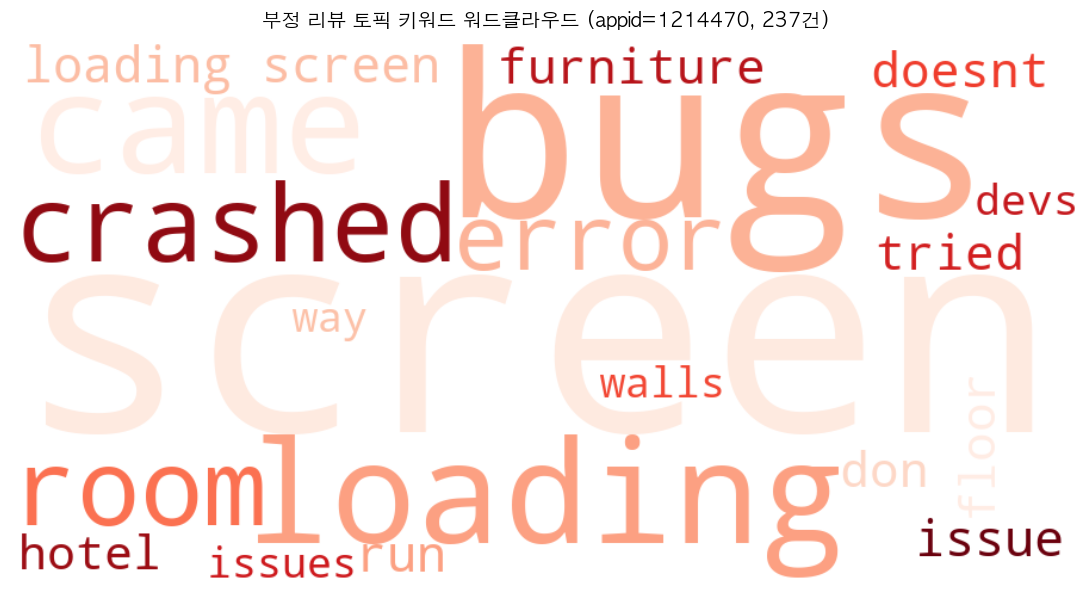

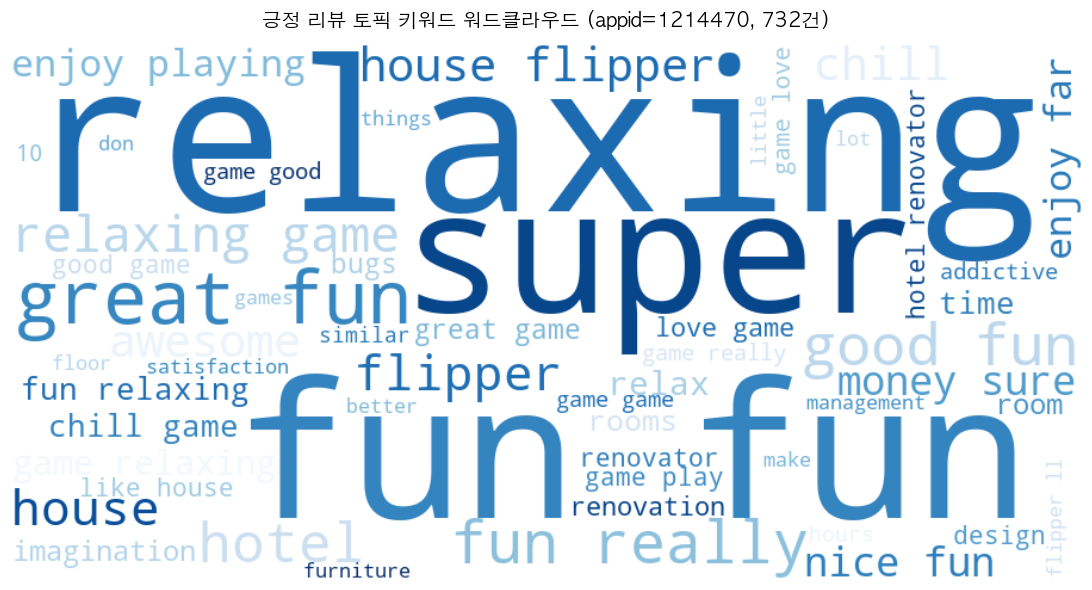

In [13]:
def make_wordcloud_from_topics(topic_model: BERTopic, title: str, colormap: str) -> None:
    info = topic_model.get_topic_info()
    info = info[info['Topic'] != -1]

    # c-TF-IDF 점수를 가중치로 사용 (건수 대신)
    word_freq = {}
    for _, row in info.iterrows():
        for word, score in topic_model.get_topic(row['Topic']):
            word_freq[word] = word_freq.get(word, 0) + score

    wc = WordCloud(
        width=900, height=450,
        background_color='white',
        colormap=colormap,
        max_words=80,
        collocations=False,
    ).generate_from_frequencies(word_freq)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()

make_wordcloud_from_topics(
    topic_model_neg,
    f'부정 리뷰 토픽 키워드 워드클라우드 (appid={TARGET_APPID}, {len(neg_docs)}건)',
    colormap='Reds',
)
make_wordcloud_from_topics(
    topic_model_pos,
    f'긍정 리뷰 토픽 키워드 워드클라우드 (appid={TARGET_APPID}, {len(pos_docs)}건)',
    colormap='Blues',
)

**해석:** 워드클라우드의 단어 크기는 c-TF-IDF 점수 기반 가중치로, 전체 리뷰 대비 해당 토픽에서 특히 두드러지는 단어일수록 크게 표시됩니다.
부정 워드클라우드에서 버그·성능 관련 단어가 두드러질수록 기술적 완성도가 주요 불만 요인임을 나타냅니다.
긍정 워드클라우드에서는 게임의 핵심 강점(아트, 스토리, 분위기 등)을 파악할 수 있습니다.

2D 임베딩 로드 완료: ../../../../data/processed/embeddings_2d_부정_1214470.npy


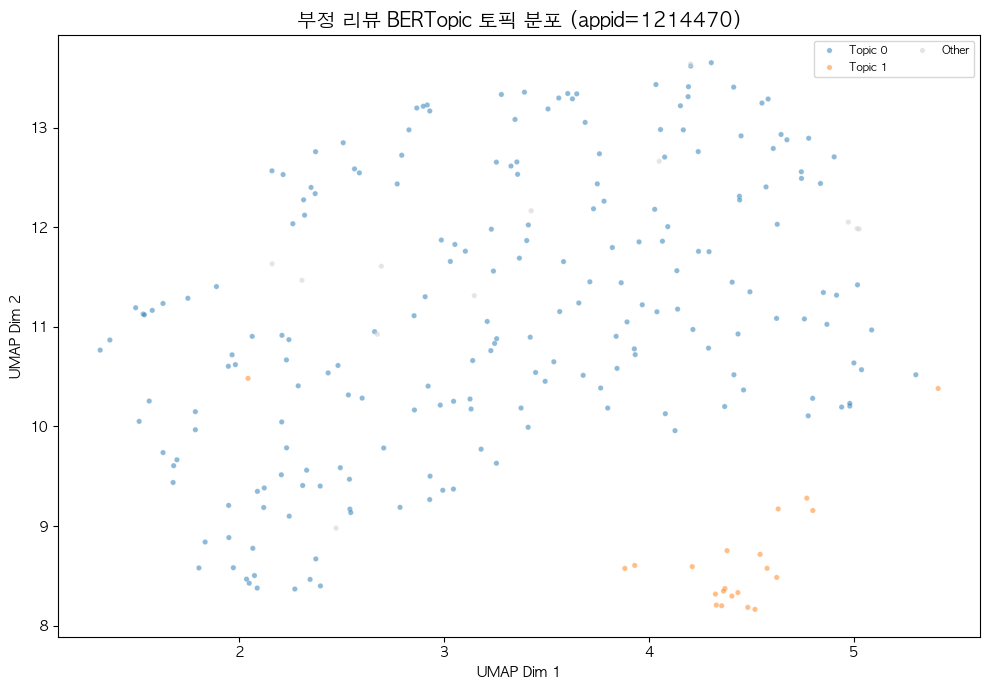

2D 임베딩 로드 완료: ../../../../data/processed/embeddings_2d_긍정_1214470.npy


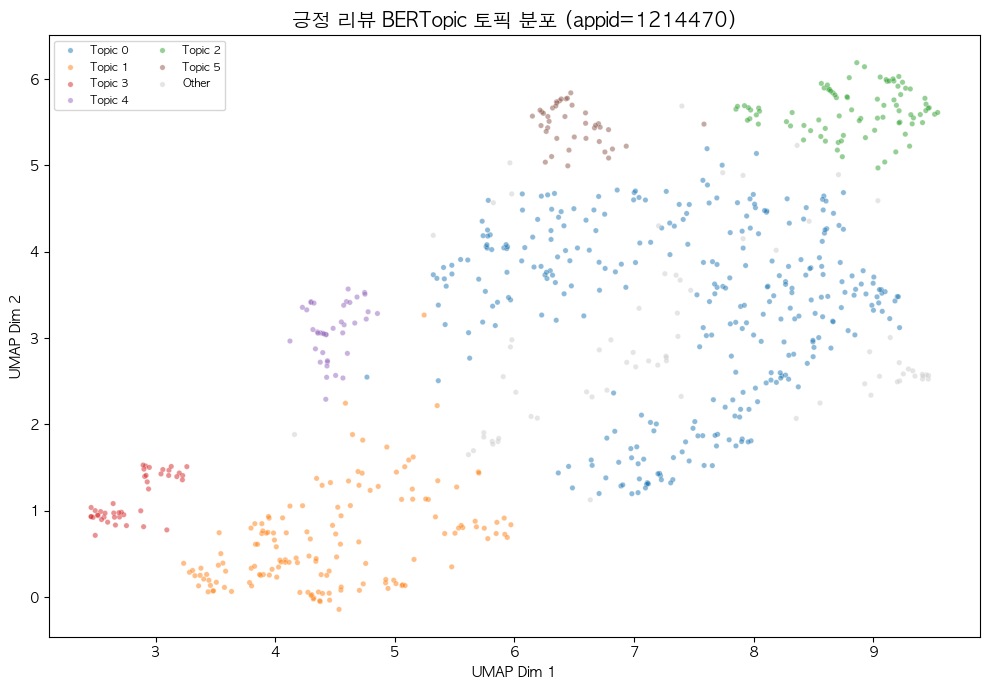

In [14]:
def plot_umap_2d(docs, embeddings, topic_model, topic_info, label, colormap, appid):
    path = f'../../../../data/processed/embeddings_2d_{label}_{appid}.npy'
    if os.path.exists(path):
        emb_2d = np.load(path)
        print(f"2D 임베딩 로드 완료: {path}")
    else:
        umap_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.0, metric="cosine", random_state=42)
        print(f"{label} 문서 UMAP 2D 축소 중...")
        emb_2d = umap_2d.fit_transform(embeddings)
        np.save(path, emb_2d)
        print(f"저장 완료: {path}")

    topics = topic_model.topics_
    top_topic_ids = [f"Topic {t}" for t in topic_info[topic_info["Topic"] != -1]["Topic"].values[:10]]

    df_viz = pd.DataFrame({
        "UMAP Dim 1": emb_2d[:, 0],
        "UMAP Dim 2": emb_2d[:, 1],
        "topic": [f"Topic {t}" if t != -1 else "Noise" for t in topics],
    })
    df_viz["topic_color"] = df_viz["topic"].apply(lambda x: x if x in top_topic_ids else "Other")

    palette = {t: c for t, c in zip(top_topic_ids, sns.color_palette("tab10", len(top_topic_ids)))}
    palette["Other"] = (0.8, 0.8, 0.8)

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=df_viz.sort_values("topic_color", key=lambda x: x == "Other"),
        x="UMAP Dim 1", y="UMAP Dim 2",
        hue="topic_color", palette=palette, alpha=0.5, s=15, ax=ax
    )
    ax.set_title(f"{label} 리뷰 BERTopic 토픽 분포 (appid={appid})", fontsize=14)
    ax.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

plot_umap_2d(neg_docs, neg_embeddings, topic_model_neg, neg_topic_info, '부정', 'Reds', TARGET_APPID)
plot_umap_2d(pos_docs, pos_embeddings, topic_model_pos, pos_topic_info, '긍정', 'Blues', TARGET_APPID)

## 카테고리 분류 (TF-IDF + 키워드 매핑)

사전 정의된 카테고리 키워드를 기반으로 각 리뷰를 분류합니다.
분류 기준이 명확하고 재현 가능하기 때문에 LLM 서술 단계의 근거 수치로 사용할 수 있습니다.

In [15]:
# 카테고리별 키워드 사전
CATEGORY_KEYWORDS = {
    "bug":         ["bug", "crash", "glitch", "broken", "freeze", "stuck", "error", "fix", "patch", "issue", "problem", "corrupt", "save"],
    "balance":     ["balance", "unfair", "overpowered", "op", "nerf", "buff", "difficulty", "hard", "easy", "rng", "random", "cheap"],
    "price":       ["price", "expensive", "cheap", "worth", "value", "money", "cost", "overpriced", "discount", "sale", "refund"],
    "performance": ["fps", "lag", "stutter", "performance", "optimize", "slow", "loading", "memory", "cpu", "gpu", "frame"],
    "content":     ["content", "short", "long", "hours", "ending", "story", "level", "map", "update", "dlc", "replay", "replayability"],
    "positive":    ["fun", "enjoy", "love", "great", "amazing", "recommend", "best", "beautiful", "art", "music", "atmosphere", "charm"],
}

# 부정 리뷰에는 positive 카테고리 제외 (부정 리뷰에도 긍정 키워드가 등장할 수 있어 오분류 방지)
NEG_CATEGORIES = {k: v for k, v in CATEGORY_KEYWORDS.items() if k != "positive"}

def classify_review(text: str, keywords: dict[str, list[str]]) -> str:
    """리뷰 텍스트에서 가장 많이 매칭된 카테고리를 반환합니다. 매칭 없으면 'other'."""
    text_lower = text.lower()
    scores = {cat: sum(1 for kw in kws if kw in text_lower) for cat, kws in keywords.items()}
    best_cat = max(scores, key=scores.get)
    return best_cat if scores[best_cat] > 0 else "other"

df_neg['category'] = df_neg['review'].apply(lambda x: classify_review(x, NEG_CATEGORIES))
df_pos['category'] = df_pos['review'].apply(lambda x: classify_review(x, CATEGORY_KEYWORDS))

# 카테고리별 건수 및 비율 집계
neg_cat_counts = df_neg['category'].value_counts()
pos_cat_counts = df_pos['category'].value_counts()

neg_cat_ratio = (neg_cat_counts / len(df_neg) * 100).round(1)
pos_cat_ratio = (pos_cat_counts / len(df_pos) * 100).round(1)

df_neg_summary = pd.DataFrame({'count': neg_cat_counts, 'ratio(%)': neg_cat_ratio})
df_pos_summary = pd.DataFrame({'count': pos_cat_counts, 'ratio(%)': pos_cat_ratio})

print("=== 부정 리뷰 카테고리 분류 ===")
display(df_neg_summary)

print("\n=== 긍정 리뷰 카테고리 분류 ===")
display(df_pos_summary)

=== 부정 리뷰 카테고리 분류 ===


,count,ratio(%)
category,,
bug,137,57.8
other,28,11.8
price,23,9.7
content,19,8.0
balance,18,7.6
performance,12,5.1



=== 긍정 리뷰 카테고리 분류 ===


,count,ratio(%)
category,,
positive,310,42.3
bug,157,21.4
other,86,11.7
content,82,11.2
balance,67,9.2
price,24,3.3
performance,6,0.8


/var/folders/0b/g0grvv6j3wgdm_gjyyd_jb7m0000gn/T/ipykernel_50455/4091087440.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bars = ax.barh(summary.index, summary['ratio(%)'], color=plt.cm.get_cmap(color)(0.5))


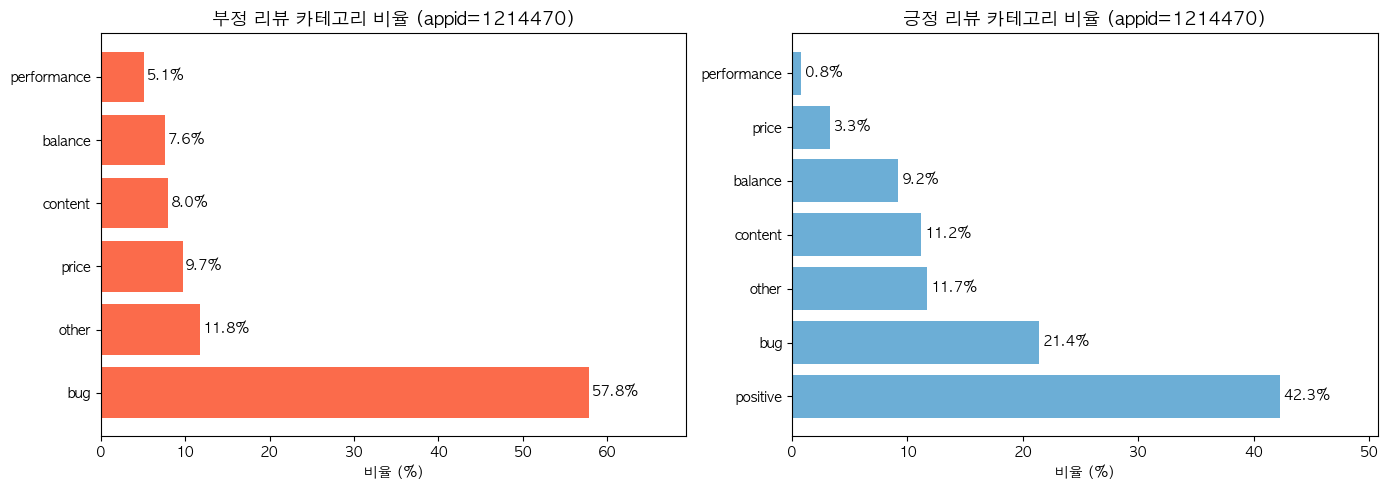

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summary, title, color in [
    (axes[0], df_neg_summary, '부정 리뷰 카테고리 비율', 'Reds_r'),
    (axes[1], df_pos_summary, '긍정 리뷰 카테고리 비율', 'Blues_r'),
]:
    bars = ax.barh(summary.index, summary['ratio(%)'], color=plt.cm.get_cmap(color)(0.5))
    ax.set_xlabel('비율 (%)')
    ax.set_title(f'{title} (appid={TARGET_APPID})', fontsize=13)
    for bar, val in zip(bars, summary['ratio(%)']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val}%', va='center', fontsize=10)
    ax.set_xlim(0, summary['ratio(%)'].max() * 1.2)

plt.tight_layout()
plt.show()

**해석:** 카테고리 분류는 사전 정의된 키워드 매핑 기반으로, 각 리뷰에서 가장 많이 매칭된 카테고리를 부여합니다.
부정 리뷰에서 비율이 높은 카테고리일수록 개발사가 우선적으로 대응해야 할 영역입니다.
`other`로 분류된 리뷰는 키워드 사전에 없는 주제를 다루며, 비율이 높다면 키워드 사전 확장을 검토하세요.
이 집계 수치는 다음 단계(LLM 서술)의 근거 데이터로 사용됩니다.

## 집계 결과 저장 (LLM 입력용)

카테고리별 비율과 BERTopic 토픽 키워드를 구조화된 JSON으로 저장합니다.
이 파일이 다음 단계(LLM 서술)의 고정된 입력 근거가 됩니다.

In [17]:
import json

def build_topic_summary(topic_model: BERTopic, topic_info: pd.DataFrame, top_n_words: int = 5) -> list[dict]:
    result = []
    for _, row in topic_info[topic_info['Topic'] != -1].iterrows():
        topic_id = row['Topic']
        keywords = [word for word, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        result.append({
            "topic_id": int(topic_id),
            "count": int(row['Count']),
            "keywords": keywords,
        })
    return result

summary = {
    "appid": TARGET_APPID,
    "total_reviews": len(df_game),
    "negative": {
        "count": len(df_neg),
        "category_ratio": df_neg_summary['ratio(%)'].to_dict(),
        "topics": build_topic_summary(topic_model_neg, neg_topic_info),
    },
    "positive": {
        "count": len(df_pos),
        "category_ratio": df_pos_summary['ratio(%)'].to_dict(),
        "topics": build_topic_summary(topic_model_pos, pos_topic_info),
    },
}

output_path = f'../../../../data/processed/review_analysis_summary_{TARGET_APPID}.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {output_path}")
print(json.dumps(summary, ensure_ascii=False, indent=2))

저장 완료: ../../../../data/processed/review_analysis_summary_1214470.json
{
  "appid": 1214470,
  "total_reviews": 969,
  "negative": {
    "count": 237,
    "category_ratio": {
      "bug": 57.8,
      "other": 11.8,
      "price": 9.7,
      "content": 8.0,
      "balance": 7.6,
      "performance": 5.1
    },
    "topics": [
      {
        "topic_id": 0,
        "count": 204,
        "keywords": [
          "bugs",
          "room",
          "floor",
          "don",
          "furniture"
        ]
      },
      {
        "topic_id": 1,
        "count": 21,
        "keywords": [
          "screen",
          "loading",
          "came",
          "crashed",
          "error"
        ]
      }
    ]
  },
  "positive": {
    "count": 732,
    "category_ratio": {
      "positive": 42.3,
      "bug": 21.4,
      "other": 11.7,
      "content": 11.2,
      "balance": 9.2,
      "price": 3.3,
      "performance": 0.8
    },
    "topics": [
      {
        "topic_id": 0,
        "count": 3